In [1]:
import os
import numpy as np

## 3 Naive bayes

In [3]:
def load_dataset(data_dir):
    labels = []
    dataset = []

    for filename in os.listdir(data_dir):
        if filename.endswith('txt'):
            with open(os.path.join(data_dir, filename), 'r', encoding='utf-8') as f:
                text = f.read()
                label = filename[0]
                dataset.append(text)
                labels.append(label)
                # leave some datasets for test
                if filename[1] != '1'  and filename[2] == '.':
                    dataset.append(text)
                    labels.append(label)
    return dataset, labels

data_dir = "./languageID/"
documents, labels = load_dataset(data_dir)

def calculate_char_frequencies(documents, labels):
    char_frequencies = {}
    total_documents = len(documents)

    for i in range(total_documents):
        document = documents[i]
        label = labels[i]
        char_count = {}
        
        for char in document:
            if char.isalpha() or char == ' ':
                if char in char_count:
                    char_count[char] += 1
                else:
                    char_count[char] = 1
        
        if label in char_frequencies:
            for char, count in char_count.items():
                if char in char_frequencies[label]:
                    char_frequencies[label][char] += count
                else:
                    char_frequencies[label][char] = count
        else:
            char_frequencies[label] = char_count
        
    return char_frequencies

char_frequencies = calculate_char_frequencies(documents, labels)

def train_naive_bayes(char_frequencies):
    # Calculate total character counts for each language
    language_char_counts = {}
    for label, char_counts in char_frequencies.items():
        total_chars = sum(char_counts.values())
        language_char_counts[label] = total_chars

    #calc prior prob
    total_documents = len(documents)
    prior_probabilities = {}
    for label, char_count in char_frequencies.items():
        prior_probabilities[label] = len([l for l in labels if l == label]) / total_documents
    
    return char_frequencies, language_char_counts, prior_probabilities

char_frequencies, language_char_counts, prior_probabilities = train_naive_bayes(char_frequencies)

def classify_document(document, char_frequencies, language_char_counts, prior_probabilities):
    best_label = None
    best_log_prob = float("-inf")
    
    for label, char_count in char_frequencies.items():
        log_prob = np.log(prior_probabilities[label])
        
        for char in document:
            if char.isalpha() or char == ' ':
                if char in char_count:
                    char_prob = (char_count[char] + 0.5) / (language_char_counts[label] + 1.5)  # 27 characters in the vocabulary
                else:
                    char_prob = 0.5 / (language_char_counts[label] + 1.5)
                
                log_prob += np.log(char_prob)
        
        if log_prob > best_log_prob:
            best_log_prob = log_prob
            best_label = label
    
    return best_label

def load_test_dataset(data_dir):
    dataset = []
    labels = []
    for filename in os.listdir(data_dir):
        if filename.endswith(".txt") and (filename[1] == '1' and filename[2] != '.'):
            with open(os.path.join(data_dir, filename), "r", encoding="utf-8") as file:
                text = file.read()
                # Extract the language label from the filename
                label = filename[0]
                # if filename[1] == 1:
                dataset.append(text)
                labels.append(label)
    return dataset, labels

In [4]:
# Example usage
test_document = """
Just testing
"""
print("Prior Probabilities = ", prior_probabilities)
test_docs, labels = load_test_dataset("./languageID/")
y_test_conf=labels[:]
print("Total Test documents =", len(test_docs))
err = 0
for i in range(len(test_docs)):
    predicted_language = classify_document(test_docs[i], char_frequencies, language_char_counts, prior_probabilities)
    # print(f"The document is classified as {predicted_language} language.", "Actual Language = ", labels[i])
    if predicted_language != labels[i]:
        err += 1
print("Correct Predictions =", len(test_docs) - err)
print("Errors = ", err)

Prior Probabilities =  {'e': 0.3333333333333333, 'j': 0.3333333333333333, 's': 0.3333333333333333}
Total Test documents = 30
Correct Predictions = 30
Errors =  0


### 3.2

In [22]:
theta_e = []
for i in 'abcdefghijklmnopqrstuvwxyz ':
    theta_e.append((i, (char_frequencies['e'][i] + 0.5) / (1.5 + language_char_counts['e'])))
print("English")
print("Class Conditional Probability = ")
# print(theta_e)

theta_english = {}
for i in theta_e:
    theta_english[i[0]] = i[1]
theta_english

English
Class Conditional Probability = 


{'a': 0.06101951293299047,
 'b': 0.01182877023143246,
 'c': 0.021933141733474514,
 'd': 0.022054152170624716,
 'e': 0.10571270105379922,
 'f': 0.019734785458579134,
 'g': 0.01660868249886553,
 'h': 0.046720112943074675,
 'i': 0.05498915948167196,
 'j': 0.000978167700297484,
 'k': 0.003963091816669187,
 'l': 0.02993999899157969,
 'm': 0.0215902788282156,
 'n': 0.05785307316089346,
 'o': 0.0649926889527555,
 'p': 0.016588514092673826,
 'q': 0.0006554732012302727,
 'r': 0.05139918317954924,
 's': 0.06430696314223769,
 't': 0.0822366762466596,
 'u': 0.02592648615943125,
 'v': 0.009267382645086471,
 'w': 0.015479251752130288,
 'x': 0.0012000201684061918,
 'y': 0.013401905914385115,
 'z': 0.0005344627640800686,
 ' ': 0.17932738365350678}

### 3.3

In [6]:
theta_s = []
for i in 'abcdefghijklmnopqrstuvwxyz ':
    theta_s.append((i, (char_frequencies['s'][i] + 0.5) / (1.5 + language_char_counts['s'])))
print("Spanish - Class Conditional Probability = ")


theta_spanish = {}
for i in theta_s:
    theta_spanish[i[0]] = i[1]
theta_spanish

Spanish - Class Conditional Probability = 


{'a': 0.1062883185936737,
 'b': 0.009169334273777875,
 'c': 0.036861808908903476,
 'd': 0.03994357332754598,
 'e': 0.11275568335955727,
 'f': 0.007715262329770495,
 'g': 0.007281211003201129,
 'h': 0.004742010742770333,
 'i': 0.049948456404969886,
 'j': 0.00673864684498942,
 'k': 0.0002495795127773859,
 'l': 0.05322554392056861,
 'm': 0.024903694861917423,
 'n': 0.05426726710433509,
 'o': 0.07136888937116814,
 'p': 0.02425261787206337,
 'q': 0.007802072595084369,
 'r': 0.05869459063534263,
 's': 0.06607346318702187,
 't': 0.03551624979653844,
 'u': 0.03460474201074277,
 'v': 0.005892246758179154,
 'w': 0.00020617438012044924,
 'x': 0.0025500515435950303,
 'y': 0.007476534100157343,
 'z': 0.0031577234007921437,
 ' ': 0.16857468395637784}

In [7]:
theta_j = []
for i in 'abcdefghijklmnopqrstuvwxyz ':
    if i in char_frequencies['j']:
        theta_j.append((i, (char_frequencies['j'][i] + 0.5) / (1.5 + language_char_counts['j'])))
    else:
        theta_j.append((i, 0.5 / (13.5 + language_char_counts['j'])))
print("Japanese - Class Conditional Probability = ")


theta_japanese = {}
for i in theta_j:
    theta_japanese[i[0]] = i[1]
theta_japanese

Japanese - Class Conditional Probability = 


{'a': 0.13230259127112842,
 'b': 0.010295407311300922,
 'c': 0.0051777369325212335,
 'd': 0.01678259511538785,
 'e': 0.06000648718780409,
 'f': 0.003616006535241047,
 'g': 0.014668252423685444,
 'h': 0.03148688747131822,
 'i': 0.0984490815823933,
 'j': 0.0021263560024507152,
 'k': 0.057675904902632115,
 'l': 0.0013094508715656948,
 'm': 0.04023257769608726,
 'n': 0.05690705301474033,
 'o': 0.09080861594646869,
 'p': 0.0007328119556468567,
 'q': 6.0066553741545636e-05,
 'r': 0.0422508139018032,
 's': 0.04256315998125924,
 't': 0.057675904902632115,
 'u': 0.0701697480808736,
 'v': 0.00020422628272125516,
 'w': 0.020170348746411024,
 'x': 1.2009848075421846e-05,
 'y': 0.013851347292800423,
 'z': 0.007748585432659386,
 ' ': 0.12300428875193714}

### 3.4

In [8]:
def create_bow_vector(filename):
    # Initialize a vector of size 27 with zeros
    bow_vector = {ch: 0 for ch in 'abcdefghijklmnopqrstuvwxyz '}
    
    with open(filename, "r", encoding="utf-8") as file:
        content = file.read().lower()
        # Count each character and update the bow_vector
        for ch in content:
            if ch in bow_vector:
                bow_vector[ch] += 1
    
    return bow_vector

# Main execution
filename = "./languageID/e10.txt"
bow_vector = create_bow_vector(filename)

print("Bag-of-Words Count Vector for e10.txt:")
for ch, count in bow_vector.items():
    print(f"{ch}: {count}")

Bag-of-Words Count Vector for e10.txt:
a: 164
b: 32
c: 53
d: 57
e: 311
f: 55
g: 51
h: 140
i: 140
j: 3
k: 6
l: 85
m: 64
n: 139
o: 182
p: 53
q: 3
r: 141
s: 186
t: 225
u: 65
v: 31
w: 47
x: 4
y: 38
z: 2
 : 498


### 3.5 and 3.6

In [23]:
import math

def compute_log_likelihood(bow_vector, theta):
    log_likelihood = 0
    for ch, count in bow_vector.items():
        # Using log to get the log likelihood
        log_likelihood += count * math.log(theta[ch])
    return log_likelihood

# Compute log-likelihoods
log_likelihood_e = compute_log_likelihood(bow_vector, theta_english)
log_likelihood_j = compute_log_likelihood(bow_vector, theta_japanese)
log_likelihood_s = compute_log_likelihood(bow_vector, theta_spanish)

# Compute log posteriors
log_posterior_e = log_likelihood_e + math.log(prior_probabilities['e'])
log_posterior_j = log_likelihood_j + math.log(prior_probabilities['j'])
log_posterior_s = log_likelihood_s + math.log(prior_probabilities['s'])

print("Log Likelihood for English:", log_likelihood_e)
print("Log Likelihood for Japanese:", log_likelihood_j)
print("Log Likelihood for Spanish:", log_likelihood_s)

import decimal
temp1 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_likelihood_e))
temp2 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_likelihood_j))
temp3 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_likelihood_s))

print("Likelihood for English:", temp1)
print("Likelihood for Japanese:", temp2)
print("Likelihood for Spanish:", temp3)

print("Log Posterior for English:", log_posterior_e)
print("Log Posterior for Japanese:", log_posterior_j)
print("Log Posterior for Spanish:", log_posterior_s)

import decimal
temp1 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_posterior_e))
temp2 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_posterior_s))
temp3 = pow(decimal.Decimal(math.exp(1)),decimal.Decimal(log_posterior_j))

print("Posterior for English: ", temp1)
print("Posterior for Spanish: ", temp2)
print("Posterior for Japanese: ", temp3)

# Predict the class label based on max log-posterior
predicted_language = max(("English", log_posterior_e), ("Japanese", log_posterior_j), ("Spanish", log_posterior_s), key=lambda x: x[1])[0]
print("Predicted class label:", predicted_language)

Log Likelihood for English: -7840.826543900948
Log Likelihood for Japanese: -8806.511181131005
Log Likelihood for Spanish: -8430.845056792668
Likelihood for English: 5.919682624732355093970989052E-3406
Likelihood for Japanese: 2.403196127564128727175589573E-3825
Likelihood for Spanish: 3.392454672433357825111779659E-3662
Log Posterior for English: -7841.925156189616
Log Posterior for Japanese: -8807.609793419673
Log Posterior for Spanish: -8431.943669081336
Posterior for English:  1.973227541577792948871180416E-3406
Posterior for Spanish:  1.130818224144648172595671318E-3662
Posterior for Japanese:  8.010653758548481123406498582E-3826
Predicted class label: English


### 3.7

30it [00:00, 216946.76it/s]


[10, 0, 0]
[0, 10, 0]
[0, 0, 10]


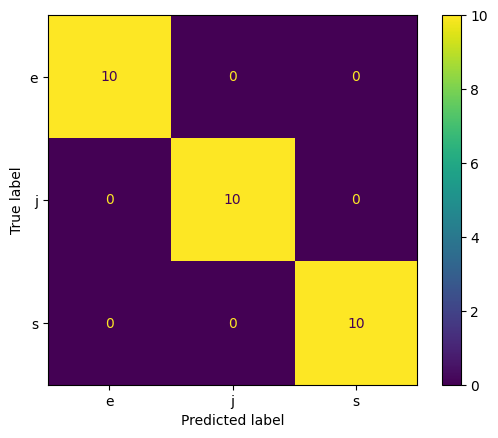

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

# Sample data (you'd replace this with your actual file loading mechanism)
documents = ["sampleEnglishText1", "sampleSpanishText1", "sampleJapaneseText1"]
labels = ["e", "s", "j"]

# Convert documents to character frequency vectors
vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 1))
X = vectorizer.fit_transform(documents)
y = labels

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Predict on the testing data
y_pred = []
for i in range(len(test_docs)):
    predicted_language = classify_document(test_docs[i], char_frequencies, language_char_counts, prior_probabilities)
    y_pred.append(predicted_language)
y_pred = np.asarray(y_pred)

confusion = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]
label_idx = {"e": 0, "s": 1, "j": 2}
for true, pred in tqdm(zip(y_test_conf, y_pred)):
    confusion[label_idx[true]][label_idx[pred]] += 1
for row in confusion:
    print(row)

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test_conf,y_pred)
# disp.plot()

## 4 Neural Networks

In [11]:
import numpy as np

# Helper functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    e_z = np.exp(z - np.max(z))
    return e_z / e_z.sum(axis=0)

# Define the feedforward and backpropagation functions
def feedforward(x, W1, W2):
    # z = np.dot(W1, x)
    z = W1 @ x
    a = sigmoid(z)
    # h = np.dot(W2, a)
    h = W2 @ a
    y_pred = softmax(h)
    # print(x.shape, W1.shape, W2.shape)
    return z, a, h, y_pred

def backpropagation(x, y, y_pred, W2, z, a):
    m = x.shape[1]
    
    dh = y_pred - y
    dW2 = 1/m * np.dot(dh, a.T)
    dz = np.dot(W2.T, dh) * sigmoid_derivative(z)
    dW1 = 1/m * np.dot(dz, x.T)
    
    return dW1, dW2

# Training the model
def train_model(X, Y, learning_rate, epochs):
    np.random.seed(42)
    W1 = np.random.randn(200, 300)
    W2 = np.random.randn(10, 200)
    
    for epoch in range(epochs):
        for x, y in zip(X, Y):
            z, a, h, y_pred = feedforward(x, W1, W2)
            dW1, dW2 = backpropagation(x, y, y_pred, W2, z, a)
            
            W1 -= learning_rate * dW1
            W2 -= learning_rate * dW2
            
    return W1, W2

### MNIST Dataset
Load dataset (Used Tensorflow to download the dataset)
Encode the labels using one-hot encoding

In [12]:
import numpy as np
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()



# Flatten the images and normalize
train_images = train_images.reshape(train_images.shape[0], -1) / 255.0
test_images = test_images.reshape(test_images.shape[0], -1) / 255.0

# Convert labels to one-hot encoded format
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

train_labels = one_hot_encode(train_labels, 10)
test_labels = one_hot_encode(test_labels, 10)

2024-10-28 23:46:49.112940: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-28 23:46:49.264448: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-28 23:46:49.386577: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-28 23:46:49.392508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730177209.403135  860349 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730177209.40

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Hyperparameters
from tqdm import tqdm
learning_rate = 0.01
epochs = 200
batch_size = 32
d1 = 300

# Weight initalization with weights = 0
# W1 = np.zeros((hidden_units, 784))
# W2 = np.zeros((10, hidden_units))

# Weight Initialization with +1 to -1
W1 = np.random.rand(d1, 784)
W2 = np.random.rand(10, d1)

W1 = 2 * W1 - 1
W2 = 2 * W2 - 1

train_loss_array = []
train_acc_array = []
test_loss_array = []
test_acc_array = []

for epoch in range(epochs):
    # Shuffle the dataset
    permutation = np.random.permutation(train_images.shape[0])
    train_images = train_images[permutation]
    train_labels = train_labels[permutation]
    
    for i in tqdm(range(0, train_images.shape[0], batch_size)):
        x_batch = train_images[i:i+batch_size]
        y_batch = train_labels[i:i+batch_size]
        
        z, a, h, y_pred = feedforward(x_batch.T, W1, W2)
        dW1, dW2 = backpropagation(x_batch.T, y_batch.T, y_pred, W2, z, a)
        
        W1 -= learning_rate * dW1
        W2 -= learning_rate * dW2
        
    # Calculate training loss and accuracy after each epoch
    _, _, _, y_train_pred = feedforward(train_images.T, W1, W2)
    _, _, _, y_test_pred = feedforward(test_images.T, W1, W2)
    train_loss = -np.mean(np.sum(train_labels * np.log(y_train_pred.T), axis=1))
    train_acc = np.mean(np.argmax(y_train_pred, axis=0) == np.argmax(train_labels, axis=1))
    test_loss = -np.mean(np.sum(test_labels * np.log(y_test_pred.T), axis=1))
    test_acc = np.mean(np.argmax(y_test_pred, axis=0) == np.argmax(test_labels, axis=1))
    
    train_loss_array.append(train_loss)
    train_acc_array.append(train_acc)
    test_loss_array.append(test_loss)
    test_acc_array.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

100%|████████████████████████████████████████████| 1875/1875 [00:01<00:00, 1214.58it/s]


Epoch 1/200, Train Loss: 0.8877, Train Accuracy: 0.7482, Test Loss: 0.8482, Test Accuracy: 0.7519


100%|████████████████████████████████████████████| 1875/1875 [00:01<00:00, 1034.34it/s]


Epoch 2/200, Train Loss: 0.6386, Train Accuracy: 0.8164, Test Loss: 0.6078, Test Accuracy: 0.8210


100%|█████████████████████████████████████████████| 1875/1875 [00:01<00:00, 943.64it/s]


...

Epoch 198/200, Train Loss: 0.0581, Train Accuracy: 0.9859, Test Loss: 0.1311, Test Accuracy: 0.9593


100%|█████████████████████████████████████████████| 1875/1875 [00:02<00:00, 921.16it/s]


Epoch 199/200, Train Loss: 0.0578, Train Accuracy: 0.9859, Test Loss: 0.1312, Test Accuracy: 0.9597


100%|████████████████████████████████████████████| 1875/1875 [00:01<00:00, 1135.54it/s]


Epoch 200/200, Train Loss: 0.0575, Train Accuracy: 0.9859, Test Loss: 0.1310, Test Accuracy: 0.9600


In [14]:
W1.shape, W2.shape

((300, 784), (10, 300))

## evaluate model

In [16]:
_, _, _, y_test_pred = feedforward(test_images.T, W1, W2)
test_loss = -np.mean(np.sum(test_labels * np.log(y_test_pred.T), axis=1))
test_acc = np.mean(np.argmax(y_test_pred, axis=0) == np.argmax(test_labels, axis=1))
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.1310, Test Accuracy: 0.9600


## Plot the Train and test Loss curve

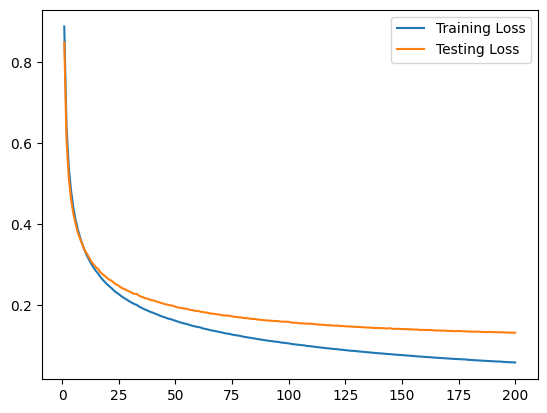

In [17]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), train_loss_array)
plt.plot(range(1, epochs+1), test_loss_array)
plt.legend(['Training Loss', "Testing Loss"])
plt.show()

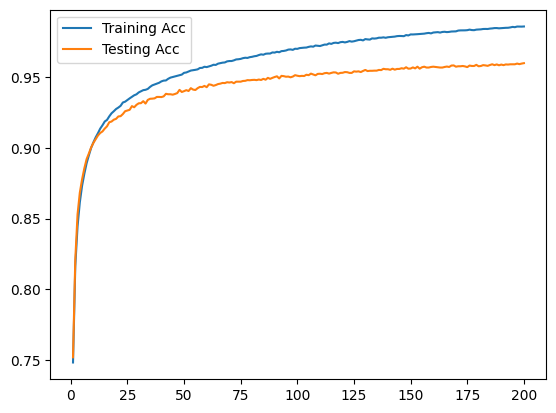

In [18]:
plt.plot(range(1, epochs+1), train_acc_array)
plt.plot(range(1, epochs+1), test_acc_array)
plt.legend(['Training Acc', "Testing Acc"])
plt.show()

## Tensorflow Implementation

In [19]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()



# Flatten the images and normalize
train_images = train_images.reshape(train_images.shape[0], -1) / 255.0
test_images = test_images.reshape(test_images.shape[0], -1) / 255.0

# Convert labels to one-hot encoded format
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

train_labels = one_hot_encode(train_labels, 10)
test_labels = one_hot_encode(test_labels, 10)

train_images.shape

(60000, 784)

/home/ssistla/private/venvs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-10-28 23:59:05.773172: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,010 (621.13 KB)

 Trainable params: 159,010 (621.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 854us/step - accuracy: 0.5598 - loss: 1.7831 - val_accuracy: 0.8371 - val_loss: 0.8123
Epoch 2/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.8417 - loss: 0.7328 - val_accuracy: 0.8715 - val_loss: 0.5413
Epoch 3/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 727us/step - accuracy: 0.8688 - loss: 0.5310 - val_accuracy: 0.8867 - val_loss: 0.4463
Epoch 4/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - accuracy: 0.8834 - loss: 0.4472 - val_accuracy: 0.8956 - val_loss: 0.3975
Epoch 5/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 878us/step - accuracy: 0.8901 - loss: 0.4080 - val_accuracy: 0.8984 - val_loss: 0.3693
Epoch 6/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - accuracy: 0.8949 - loss: 0.3793 - val_accuracy: 0.9032 - val_loss: 0.3526
Epoch 7/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8993 - loss: 0.3633 - val_accuracy: 0.9058 - val_loss: 0.3350
Epoch 8/200
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - accuracy: 

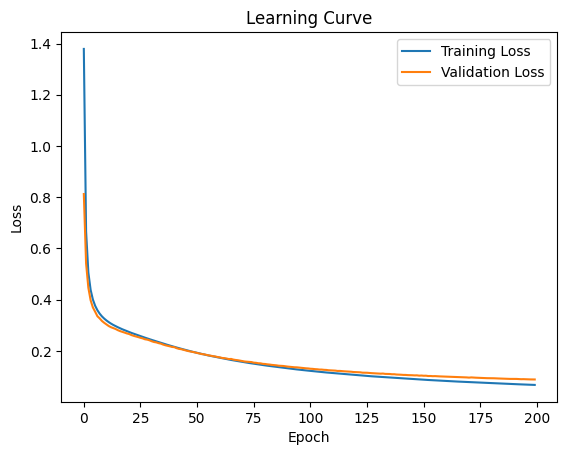

In [20]:
# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(200, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])


# Compile the model
model.compile(optimizer='sgd', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()
# Train the model and store history
history = model.fit(train_images, train_labels, epochs=200, batch_size=32, validation_data=(test_images, test_labels))

# Plot the learning curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

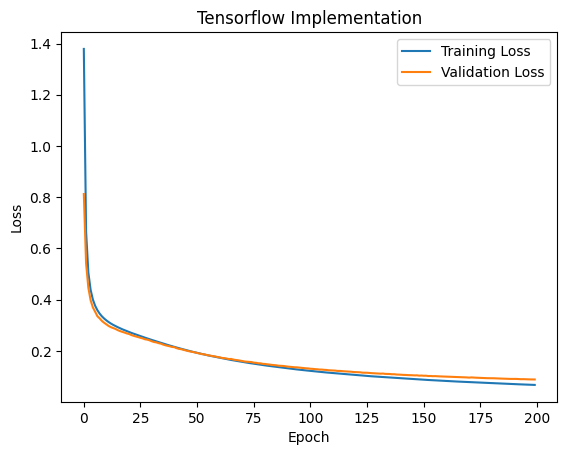

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Tensorflow Implementation')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

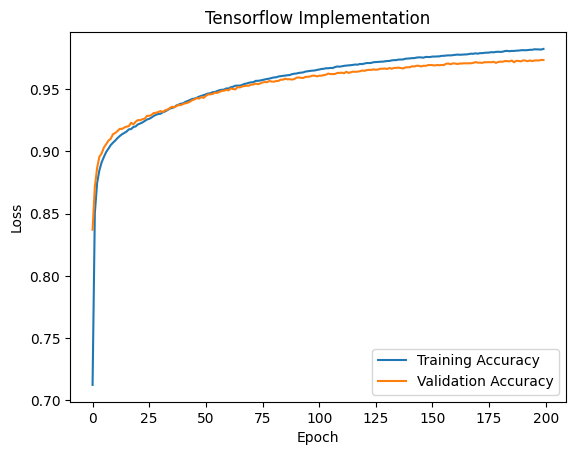

In [25]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Tensorflow Implementation')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()